# exp_ana_gis

## 0. 开头与公共准备

### 0.1 Notebook 目标与结构说明
本 notebook 以 `研究框架.md` 的附录 C 与附录 D 为统一参照，把参考实验重新整理为 `GIS` 主线。整个实验按照“微观建模 -> 宏观构造 -> 宏微比较 -> CE 计算”的顺序展开，并进一步加入 `step2` 系统下的 SVD / EVD 对比。

### 0.2 公共依赖、绘图风格与统一参数
这一块负责导入依赖、定位仓库根目录、设置绘图风格，并统一默认参数。后续默认采用
\[
\tau = 1, \qquad \alpha = 1,
\]
噪声默认取高斯噪声，热力图统一使用 `vlag` 色图。这样后面每一部分只需要改少量参数，就可以复用同一套分析函数。


In [1]:
import sys
from pathlib import Path
REPO_ROOT = None
for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (candidate / 'tools' / 'tools.py').exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError('Could not locate repository root containing tools/tools.py')
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap
import seaborn as sns
from IPython.display import display

from tools.tools import (
    make_step_system_matrix, step_map, observable_step, observable_step2,
    simulate_discrete_system, add_gaussian_noise, prepare_time_pairs,
    fit_linear_gis_from_pairs, fit_linear_gis_from_matrix,
    compute_gis_metrics, compute_prediction_errors, compute_ce_from_micro_macro,
    select_macro_rank, build_w_from_svd, build_w_from_evd,
    apply_coarse_graining, summarize_pipeline_results,
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 160
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'DejaVu Sans']
HEATMAP_CMAP = 'vlag'
DEFAULT_CONFIG = {'tau': 1, 'delta': None, 'alpha': 1.0, 'noise_scale': 0.05, 'eps': 1e-10, 'ridge': 1e-10, 'manual_r': 1}
DEFAULT_CONFIG


{'tau': 1,
 'delta': None,
 'alpha': 1.0,
 'noise_scale': 0.05,
 'eps': 1e-10,
 'ridge': 1e-10,
 'manual_r': 1}

### 0.3 公共函数区（本实验特有的，不包括复用 `tools.py` 里面的函数）
这里集中定义 notebook 自己用到的辅助函数，主要做三件事：

1. 统一绘图风格，例如矩阵热力图、奇异值谱和标准化曲线；
2. 支撑第一部分的参数扫描与谱图展示；
3. 把附录 D 的主流程打包成一个可以重复调用的实验函数。

其中最核心的包装逻辑是
\[
\mathbf{o}_t \rightarrow (A_o,\Sigma_o) \rightarrow W \rightarrow \mathbf{z}_t \rightarrow (A_z,\Sigma_z) \rightarrow CE,
\]
这样第三部分和第四部分就可以共享同一套流程。


In [2]:
def sparse_labels(labels, step=1):
    if labels is None:
        return False
    if step <= 1:
        return labels
    return [label if i % step == 0 else '' for i, label in enumerate(labels)]

def plot_matrix_heatmap(matrix, title, row_labels=None, col_labels=None, center=0.0, figsize=(6, 6), label_step=1, cmap=HEATMAP_CMAP):
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(np.asarray(matrix), ax=ax, cmap=cmap, center=center, square=np.asarray(matrix).shape[0]==np.asarray(matrix).shape[1], xticklabels=sparse_labels(col_labels, label_step), yticklabels=sparse_labels(row_labels, label_step))
    ax.set_title(title)
    plt.tight_layout(); plt.show()

def standardize_for_plot(x):
    x = np.asarray(x, dtype=float)
    return (x - np.mean(x)) / (np.std(x) + 1e-12)

def generate_parameter_scan_results(lam_values=None, log_min=-4, log_max=4, n_points=120):
    if lam_values is None:
        lam_values = [0.0001,0.0002,0.0005,0.001,0.002,0.005,0.01,0.02,0.05,0.1,0.2,0.5,1.0]
    ratios = 10 ** np.linspace(log_min, log_max, n_points)
    results = {}
    for lam in lam_values:
        results[lam] = {'ratios': ratios, 'sv1': [], 'sv2': [], 'sv3': []}
        for ratio in ratios:
            mu = lam / ratio
            sv = np.sort(np.linalg.svd(make_step_system_matrix(lam, mu), compute_uv=False))[::-1]
            results[lam]['sv1'].append(sv[0]); results[lam]['sv2'].append(sv[1]); results[lam]['sv3'].append(sv[2])
    return results, lam_values, ratios

def plot_singular_values_boxplot(results, lam_values, ratios):
    rows = []
    for lam in lam_values:
        for i, ratio in enumerate(ratios):
            lbl = f"$10^{{{np.log10(ratio):.0f}}}$"
            rows += [
                {'Ratio': lbl, 'Singular Value': results[lam]['sv1'][i], 'Type': '$\sigma_1$'},
                {'Ratio': lbl, 'Singular Value': results[lam]['sv2'][i], 'Type': '$\sigma_2$'},
                {'Ratio': lbl, 'Singular Value': results[lam]['sv3'][i], 'Type': '$\sigma_3$'},
            ]
    df = pd.DataFrame(rows)
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=df, x='Ratio', y='Singular Value', hue='Type', palette='Set2')
    plt.yscale('log'); plt.xlabel('$\lambda / \mu$ ratio'); plt.ylabel('Singular value'); plt.tight_layout(); plt.show()

def project_matrix_with_w(A, Sigma, W):
    return W @ A @ W.T, W @ Sigma @ W.T

def run_gis_pipeline_from_observations(observations, tau=1, alpha=1.0, delta=None, eps=1e-10, ridge=1e-10, manual_r=1, horizons=(1,3,5), w_method='svd', evd_mode='eig_abs'):
    X_now, X_next = prepare_time_pairs(observations, tau=tau, burn_in=0, stride=1)
    micro_fit = fit_linear_gis_from_pairs(X_now, X_next, fit_intercept=False, ridge=ridge, regularization=eps)
    micro_metrics = compute_gis_metrics(micro_fit['A'], micro_fit['Sigma'], alpha=alpha, eps=eps)
    micro_errors = compute_prediction_errors(micro_fit['A'], observations, tau=tau, horizons=horizons)
    rank_values = micro_metrics['sv_backward'] if w_method == 'svd' else np.abs(np.linalg.eigvals(micro_fit['A']))
    r, rank_meta = select_macro_rank(rank_values, mode='manual', manual_r=manual_r, eps=eps)
    w_result = build_w_from_svd(micro_fit['A'], micro_fit['Sigma'], r=r, alpha=alpha, eps=eps, mode='two_stage') if w_method == 'svd' else build_w_from_evd(micro_fit['A'], r=r, mode=evd_mode)
    W = w_result['W']
    macro_observations = apply_coarse_graining(W, observations)
    Z_now, Z_next = prepare_time_pairs(macro_observations, tau=tau, burn_in=0, stride=1)
    macro_fit = fit_linear_gis_from_pairs(Z_now, Z_next, fit_intercept=False, ridge=ridge, regularization=eps)
    macro_metrics = compute_gis_metrics(macro_fit['A'], macro_fit['Sigma'], alpha=alpha, eps=eps)
    macro_errors = compute_prediction_errors(macro_fit['A'], macro_observations, tau=tau, horizons=horizons)
    ce_result = compute_ce_from_micro_macro(micro_metrics, macro_metrics)
    summary_dict, summary_row = summarize_pipeline_results(
        config={'tau': tau, 'delta': delta, 'alpha': alpha, 'w_method': w_method, 'manual_r': manual_r},
        micro_fit=micro_fit, macro_fit=macro_fit, micro_metrics=micro_metrics, macro_metrics=macro_metrics,
        prediction_results={'micro_errors': micro_errors, 'macro_errors': macro_errors}, ce_result=ce_result,
        extra={'rank_meta': rank_meta, 'w_result': w_result},
    )
    return {'micro_fit': micro_fit, 'micro_metrics': micro_metrics, 'micro_errors': micro_errors, 'rank_meta': rank_meta, 'w_result': w_result, 'W': W, 'macro_observations': macro_observations, 'macro_fit': macro_fit, 'macro_metrics': macro_metrics, 'macro_errors': macro_errors, 'ce_result': ce_result, 'summary_dict': summary_dict, 'summary_row': summary_row}


## 第一部分：参数影响实验

### 1.1 第一类系统与本部分目标
本部分研究的第一类系统为
\[
\begin{aligned}
x_{k+1} &= \lambda x_k,\\
y_{k+1} &= \mu y_k + (\lambda^2 - \mu) x_k^2.
\end{aligned}
\]
在观测函数
\[
g(x,y)=[x,\;y,\;x^2]^\top
\]
下，其观测层解析矩阵可以直接写出。这里暂时不走完整 `GIS` 流程，而是先观察不同参数下奇异值谱是否出现明显分离。

### 1.2 解析矩阵与参数扫描设定
下面对一组 \[\lambda\] 取值和一组 \[\lambda / \mu\] 比例进行扫描，并绘制奇异值谱的箱型图。若谱之间出现明显断层，后续粗粒化往往更容易提取出稳定的低维宏观方向。


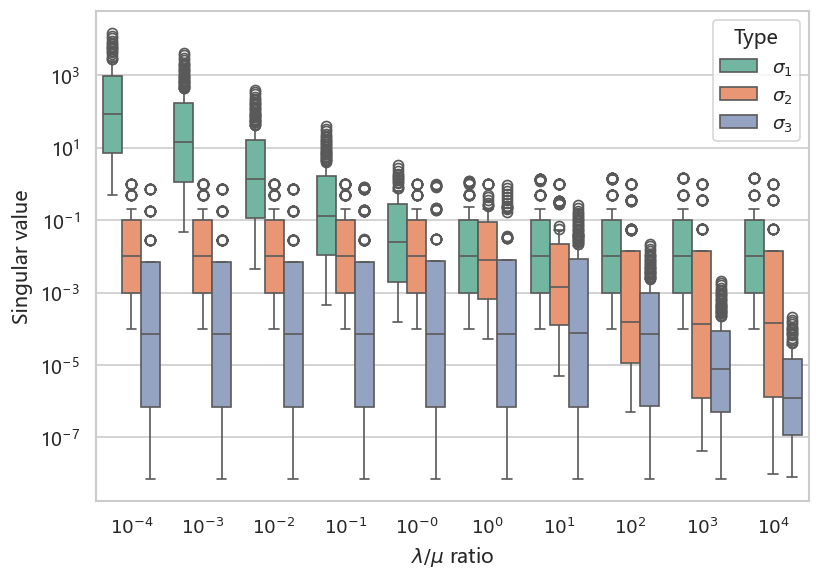

In [3]:
scan_results, scan_lam_values, scan_ratios = generate_parameter_scan_results()
plot_singular_values_boxplot(scan_results, scan_lam_values, scan_ratios)


### 1.2 参数扫描结果的补充说明
箱型图提供的是整体分布信息。为了更具体地看清某一组参数下矩阵本身的尺度关系，下面补充展示一组代表性参数对应的解析矩阵奇异值。这样后面看宏观维度选择时，会更容易理解为什么某些维度会被保留下来。


In [4]:
example_lam, example_mu = 0.1, 0.9
example_A = make_step_system_matrix(example_lam, example_mu)
example_sv = np.sort(np.linalg.svd(example_A, compute_uv=False))[::-1]
display(pd.DataFrame({'singular_index': [1, 2, 3], 'singular_value': example_sv}))


,singular_index,singular_value
0,1,1.26576
1,2,0.10000
2,3,0.00711


### 1.3 固定参数下的轨迹相图
下面固定一组代表性参数，从多个初值出发生成轨迹，并在相空间中画出渐变轨迹。这个图的作用主要是帮助直观理解系统在状态空间中的收缩路径与组织方式，也为后面解释低维主方向提供几何背景。


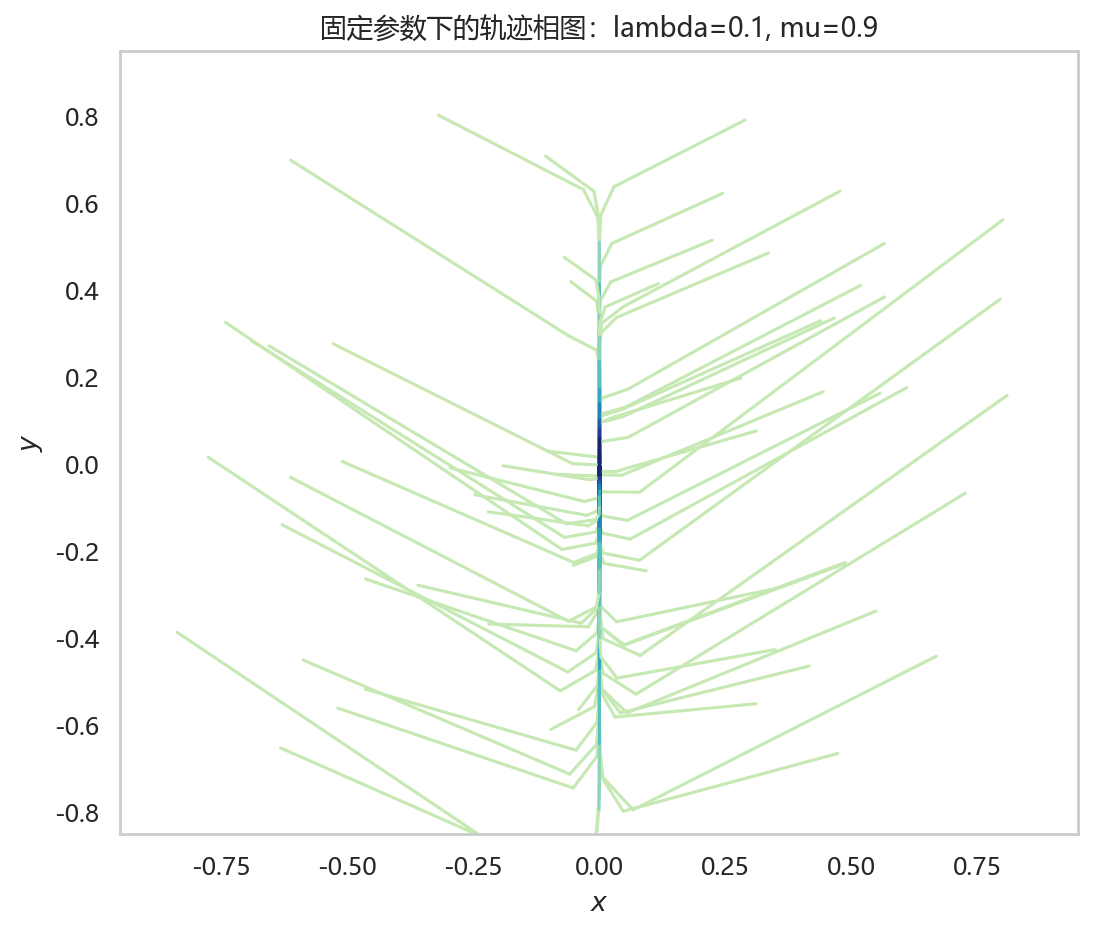

In [5]:
phase_lam, phase_mu, phase_steps, num_samples = 0.1, 0.9, 50, 60
rng = np.random.default_rng(42)
initial_points = np.vstack([rng.uniform(-0.85, 0.85, num_samples), rng.uniform(-0.7, 0.85, num_samples)]).T
fig, ax = plt.subplots(figsize=(7, 6), dpi=160)
custom_cmap = ListedColormap(plt.cm.YlGnBu(np.linspace(0.25, 0.95, 8)))
for x0, y0 in initial_points:
    traj = simulate_discrete_system(step_map, [x0, y0], steps=phase_steps, system_kwargs={'lam': phase_lam, 'mu': phase_mu}, dt=1.0)['trajectories'][0]
    points = traj.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    color_idx = np.arange(len(segments)); color_idx[np.where(color_idx > 20)] = 20
    lc = LineCollection(segments, cmap=custom_cmap); lc.set_array(color_idx); lc.set_linewidth(1.4); lc.set_capstyle('round'); ax.add_collection(lc)
ax.set_title(f'固定参数下的轨迹相图：lambda={phase_lam}, mu={phase_mu}')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$'); ax.set_xlim([-0.95, 0.95]); ax.set_ylim([-0.85, 0.95]); ax.grid(False); plt.tight_layout(); plt.show()


## 第二部分：已知解析矩阵 A / K_raw 的矩阵分析

### 2.1 本部分的目标与和主流程的关系
本部分不从数据出发，而是直接给定解析矩阵 `A`。我们把它视为观测层微观 `GIS` 的动力学矩阵，并在近零噪声条件下单独分析矩阵本身。这样可以把“矩阵结构的贡献”和“数据拟合误差的影响”分开来看。

### 2.2 给定解析矩阵与无噪声设定
这里固定参数后直接构造解析矩阵 `A`，并把噪声协方差设为近零对角形式。换句话说，这一部分等价于已知
\[
\mathbf{o}_{t+\tau} \approx A_o \mathbf{o}_t + \varepsilon_t^{(o)}, \qquad \Sigma_o \approx 0,
\]
只不过为了数值稳定，协方差矩阵会保留一个很小的正则项。


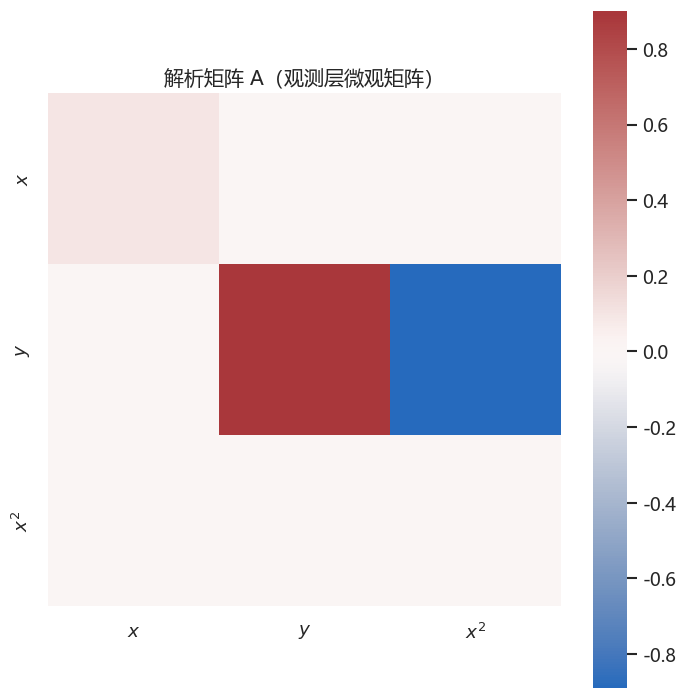

In [6]:
direct_config = {'lam': 0.1, 'mu': 0.9, 'alpha': 1.0, 'eps': 1e-10, 'manual_r': 1}
direct_feature_names = ['$x$', '$y$', '$x^2$']
A_direct = make_step_system_matrix(direct_config['lam'], direct_config['mu'])
direct_fit = fit_linear_gis_from_matrix(A_direct, Sigma=None, sigma_eps=1e-10)
Sigma_direct = direct_fit['Sigma']
plot_matrix_heatmap(A_direct, '解析矩阵 A（观测层微观矩阵）', row_labels=direct_feature_names, col_labels=direct_feature_names, label_step=1)


### 2.3 微观层 GIS 指标计算
在微观层，核心量包括
\[
\Gamma_\alpha^{\mathrm{GIS}}(A,\Sigma),
\qquad
D(\Sigma)=\log \operatorname{pdet}(\Sigma^{-1}),
\qquad
N(A,\Sigma)=\log \operatorname{pdet}(A^\top \Sigma^{-1} A),
\]
以及维度平均效率
\[
J_\alpha^{\mathrm{GIS}}(A,\Sigma;d)=\frac{1}{d}\log \Gamma_\alpha^{\mathrm{GIS}}(A,\Sigma).
\]
下面先在微观层上计算这些量，并画出与非简并性相关的奇异值谱。


,metric,value
0,Gamma,5.773503e+12
1,log_Gamma,2.938430e+01
2,J_alpha,9.794767e+00
3,D,6.578172e+01
4,N,5.175548e+01


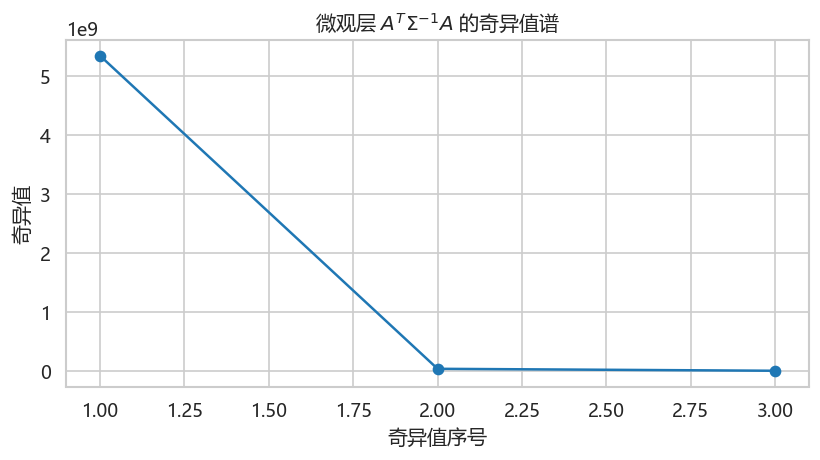

In [7]:
direct_micro_metrics = compute_gis_metrics(A_direct, Sigma_direct, alpha=direct_config['alpha'], eps=direct_config['eps'])
display(pd.DataFrame({'metric': ['Gamma','log_Gamma','J_alpha','D','N'], 'value': [direct_micro_metrics['Gamma'], direct_micro_metrics['log_Gamma'], direct_micro_metrics['J_alpha'], direct_micro_metrics['D'], direct_micro_metrics['N']]}))
plt.figure(figsize=(7,4))
plt.plot(np.arange(1, len(direct_micro_metrics['sv_backward'])+1), direct_micro_metrics['sv_backward'], marker='o', color='tab:blue')
plt.title('微观层 $A^T\Sigma^{-1}A$ 的奇异值谱')
plt.xlabel('奇异值序号')
plt.ylabel('奇异值')
plt.tight_layout(); plt.show()


### 2.4 宏观维度选择与粗粒化矩阵构造
这一步根据微观层谱结构选择宏观维度 `r`，并构造粗粒化矩阵 `W`。在线性情形下，宏观变量由
\[
\mathbf{z}_t = W \mathbf{o}_t
\]
给出。这里采用 SVD 路线来提取主方向，再把这些方向组合为宏观变量。


选定的宏观维度 r = 1


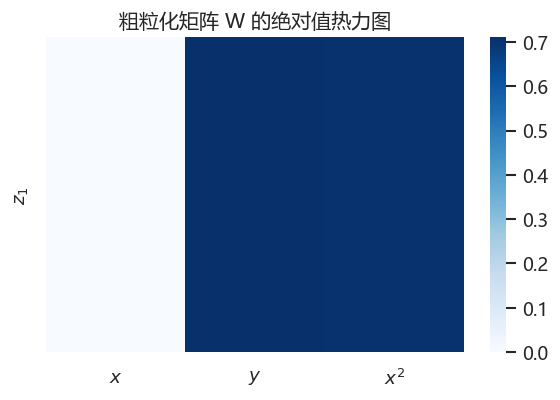

In [8]:
direct_r, _ = select_macro_rank(direct_micro_metrics['sv_backward'], mode='manual', manual_r=direct_config['manual_r'], eps=direct_config['eps'])
direct_w_result = build_w_from_svd(A_direct, Sigma_direct, r=direct_r, alpha=direct_config['alpha'], eps=direct_config['eps'], mode='two_stage')
W_direct = direct_w_result['W']
print('选定的宏观维度 r =', direct_r)
plot_matrix_heatmap(np.abs(W_direct), '粗粒化矩阵 W 的绝对值热力图', row_labels=[f'$z_{i+1}$' for i in range(W_direct.shape[0])], col_labels=direct_feature_names, center=None, figsize=(5, 3.5), cmap='Blues')


### 2.5 宏观层矩阵分析
在矩阵层面，宏观矩阵与宏观协方差可以写成
\[
A_z = W A W^\top,
\qquad
\Sigma_z = W \Sigma W^\top.
\]
下面先把解析矩阵投影到宏观层，并绘制宏观层矩阵的热力图。这样可以先看清宏观动力学的形状，再单独计算宏观指标。


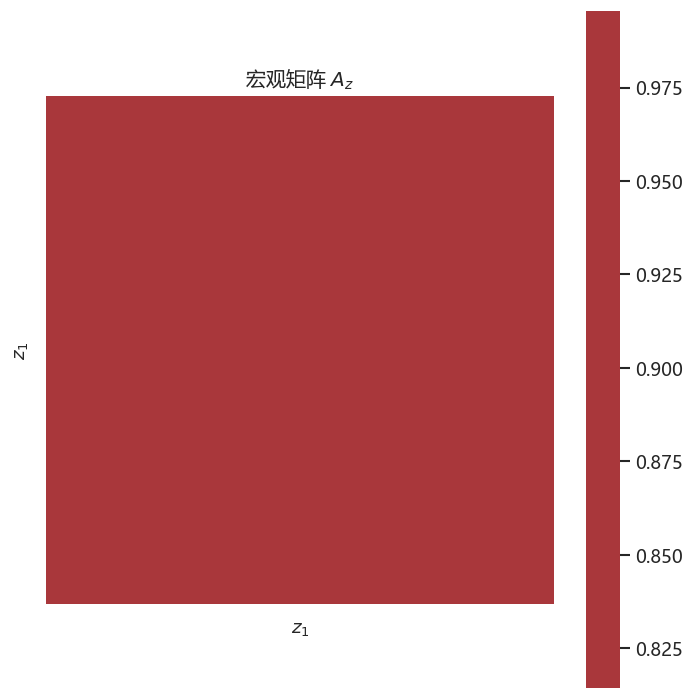

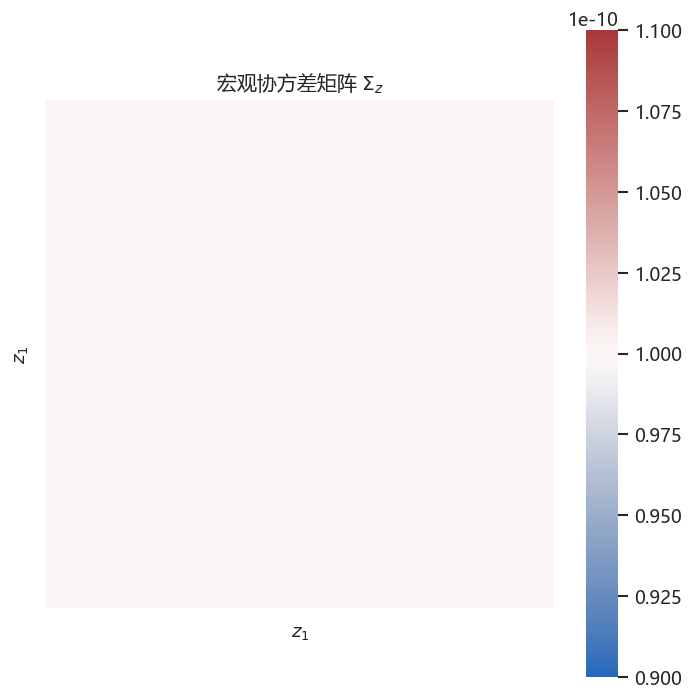

In [9]:
A_direct_macro, Sigma_direct_macro = project_matrix_with_w(A_direct, Sigma_direct, W_direct)
macro_names_direct = [f'$z_{i+1}$' for i in range(direct_r)]
plot_matrix_heatmap(A_direct_macro, '宏观矩阵 $A_z$', row_labels=macro_names_direct, col_labels=macro_names_direct, label_step=1)
plot_matrix_heatmap(Sigma_direct_macro, '宏观协方差矩阵 $\Sigma_z$', row_labels=macro_names_direct, col_labels=macro_names_direct, center=None, label_step=1)


### 2.6 宏观层 GIS 指标计算
宏观层也需要计算与微观层完全对应的一组指标。只有在同时得到
\[
(A_o, \Sigma_o) \quad \text{与} \quad (A_z, \Sigma_z)
\]
之后，才能真正比较宏观与微观的效率差异。下面给出宏观层的数值指标和奇异值谱。


,metric,value
0,Gamma,54921.661563
1,log_Gamma,10.913663
2,J_alpha,10.913663
3,D,21.927239
4,N,21.727414


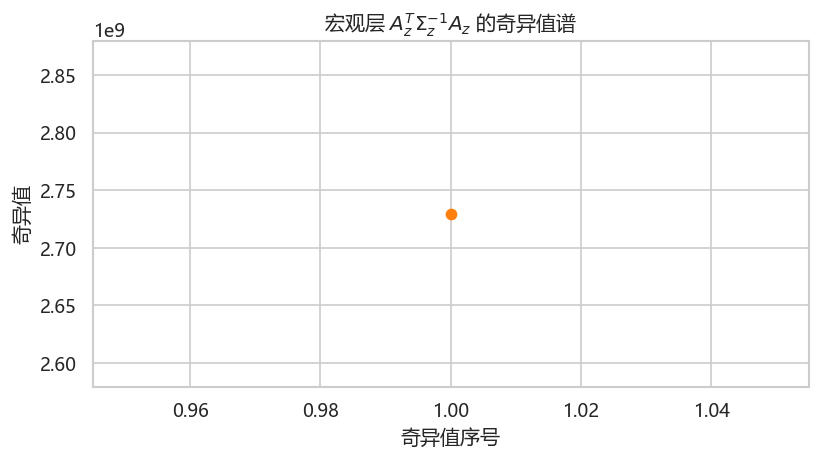

In [10]:
direct_macro_metrics = compute_gis_metrics(A_direct_macro, Sigma_direct_macro, alpha=direct_config['alpha'], eps=direct_config['eps'])
display(pd.DataFrame({'metric': ['Gamma','log_Gamma','J_alpha','D','N'], 'value': [direct_macro_metrics['Gamma'], direct_macro_metrics['log_Gamma'], direct_macro_metrics['J_alpha'], direct_macro_metrics['D'], direct_macro_metrics['N']]}))
plt.figure(figsize=(7,4))
plt.plot(np.arange(1, len(direct_macro_metrics['sv_backward'])+1), direct_macro_metrics['sv_backward'], marker='o', color='tab:orange')
plt.title('宏观层 $A_z^T\Sigma_z^{-1}A_z$ 的奇异值谱')
plt.xlabel('奇异值序号')
plt.ylabel('奇异值')
plt.tight_layout(); plt.show()


### 2.7 CE：矩阵层面的宏微比较
矩阵层面的 `CE` 定义为宏观层与微观层维度平均效率之差：
\[
CE = \Delta J_\alpha = J_{\alpha,z} - J_{\alpha,o}.
\]
下面把两层的核心指标放在一起比较，并输出矩阵层面的 `CE`。


In [11]:
direct_ce = compute_ce_from_micro_macro(direct_micro_metrics, direct_macro_metrics)
display(pd.DataFrame({'layer': ['micro','macro'], 'J_alpha': [direct_micro_metrics['J_alpha'], direct_macro_metrics['J_alpha']], 'D': [direct_micro_metrics['D'], direct_macro_metrics['D']], 'N': [direct_micro_metrics['N'], direct_macro_metrics['N']], 'log_Gamma': [direct_micro_metrics['log_Gamma'], direct_macro_metrics['log_Gamma']]}))
print('矩阵层面的 CE =', direct_ce['CE'])


,layer,J_alpha,D,N,log_Gamma
0,micro,9.794767,65.781716,51.755484,29.384300
1,macro,10.913663,21.927239,21.727414,10.913663


矩阵层面的 CE = 1.1188964254789049


## 第三部分：利用系统生成含噪数据，并走完整 GIS 主流程

### 3.1 本部分目标与主流程说明
这一部分从数据开始，完整走一遍附录 D 的主流程：数据生成、观测、微观拟合、宏观构造、宏观拟合、指标计算、预测比较和最终 `CE`。这也是后面做参数实验时最重要的主流程版本。

### 3.2 数据生成与噪声设定
先由第一类系统生成干净轨迹，再叠加可控高斯噪声。这里的噪声默认来自标准正态分布，并乘以 `noise_scale` 控制强度。这样我们就能同时看到系统本身的轨迹结构和噪声进入后的观测变化。


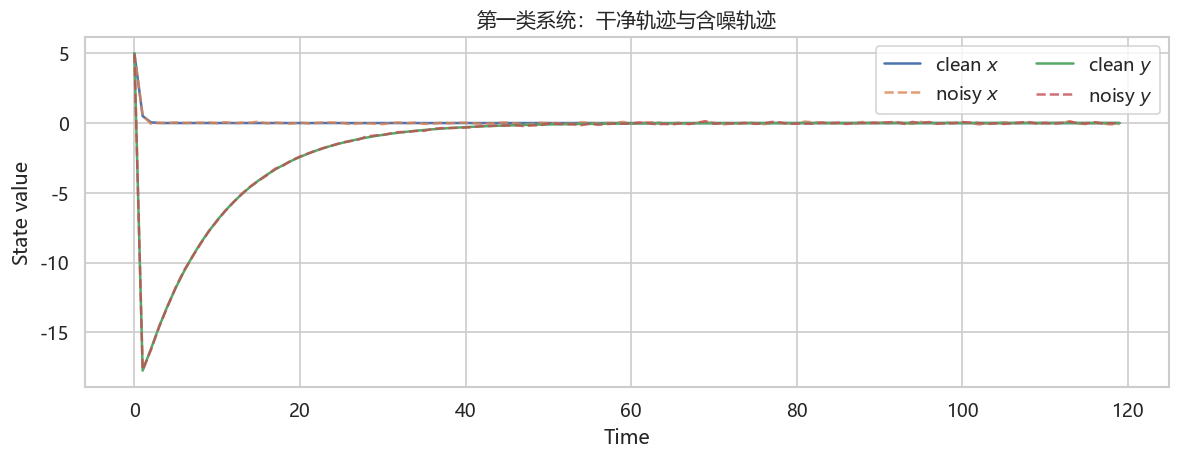

In [12]:
analysis_config = {'experiment_name': 'exp_ana_gis_part3', 'lam': 0.1, 'mu': 0.9, 'initial_state': [5.0, 5.0], 'steps': 600, 'dt': 1.0, 'tau': 1, 'delta': None, 'alpha': 1.0, 'noise_scale': 0.05, 'noise_seed': 42, 'eps': 1e-10, 'ridge': 1e-10, 'manual_r': 1, 'horizons': (1, 3, 5)}
clean_sim = simulate_discrete_system(step_map, analysis_config['initial_state'], steps=analysis_config['steps'], system_kwargs={'lam': analysis_config['lam'], 'mu': analysis_config['mu']}, dt=analysis_config['dt'])
clean_xy = clean_sim['trajectories'][0]; time_grid = clean_sim['time_grid']
noisy_xy = add_gaussian_noise(clean_xy, noise_scale=analysis_config['noise_scale'], cov=None, random_state=analysis_config['noise_seed'])['noisy_data']
plt.figure(figsize=(10,4))
plt.plot(time_grid[:120], clean_xy[:120,0], label='clean $x$')
plt.plot(time_grid[:120], noisy_xy[:120,0], '--', alpha=0.8, label='noisy $x$')
plt.plot(time_grid[:120], clean_xy[:120,1], label='clean $y$')
plt.plot(time_grid[:120], noisy_xy[:120,1], '--', alpha=0.8, label='noisy $y$')
plt.title('第一类系统：干净轨迹与含噪轨迹')
plt.xlabel('Time')
plt.ylabel('State value')
plt.legend(ncol=2)
plt.tight_layout(); plt.show()


### 3.3 观测函数、时间尺度与样本配对
这里固定观测函数
\[
g(x,y)=[x,\;y,\;x^2]^\top,
\]
并根据时间尺度 `\tau` 构造观测层配对样本
\[
(\mathbf{o}_t, \mathbf{o}_{t+\tau}).
\]
这一层的观测变量就是后续微观 `GIS` 的输入，因此这一步实际上决定了微观层的比较对象。


In [13]:
obs_part3 = observable_step(noisy_xy, mode='default')
X_now_3, X_next_3 = prepare_time_pairs(obs_part3, tau=analysis_config['tau'], burn_in=0, stride=1)
feature_names_3 = ['$x$', '$y$', '$x^2$']
print('观测层数据形状:', obs_part3.shape)
print('配对样本形状:', X_now_3.shape, X_next_3.shape)


观测层数据形状: (601, 3)
配对样本形状: (600, 3) (600, 3)


### 3.4 微观层 A / K_raw 与 Sigma 的拟合
在观测层上拟合线性 `GIS`：
\[
\mathbf{o}_{t+\tau} \approx A_o \mathbf{o}_t + \varepsilon_t^{(o)}.
\]
这里的 `A_o` 由数据回归得到，可视作经验 `K_raw`；而 `\Sigma_o` 则由一步残差协方差估计得到：
\[
\mathbf{e}_t^{(o)} = \mathbf{o}_{t+\tau} - A_o \mathbf{o}_t,
\qquad
\Sigma_o = \mathrm{Cov}(\mathbf{e}_t^{(o)}).
\]


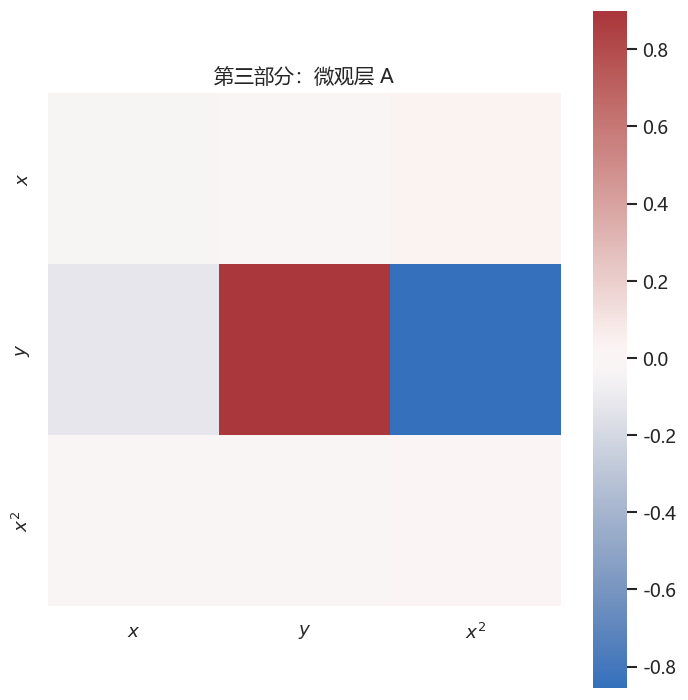

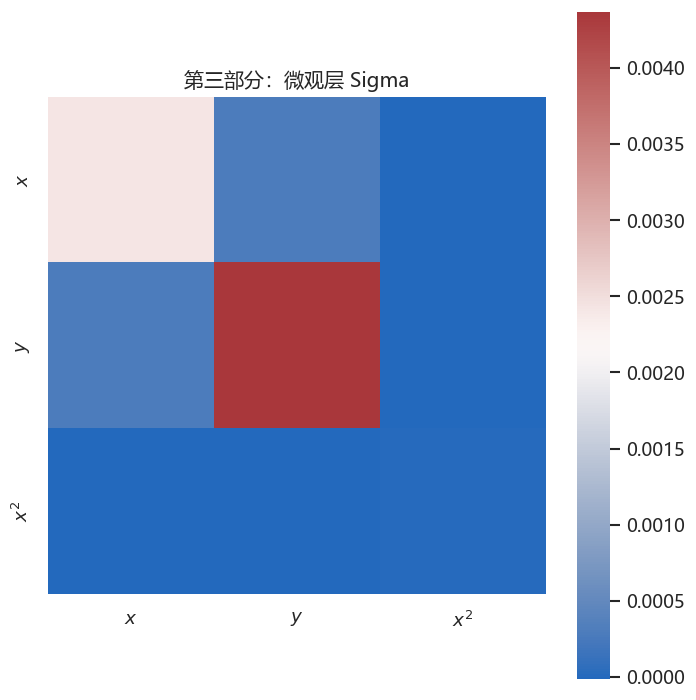

In [14]:
fit3_micro = fit_linear_gis_from_pairs(X_now_3, X_next_3, fit_intercept=False, ridge=analysis_config['ridge'], regularization=analysis_config['eps'])
A3_micro = fit3_micro['A']; Sigma3_micro = fit3_micro['Sigma']
plot_matrix_heatmap(A3_micro, '第三部分：微观层 A', row_labels=feature_names_3, col_labels=feature_names_3, label_step=1)
plot_matrix_heatmap(Sigma3_micro, '第三部分：微观层 Sigma', row_labels=feature_names_3, col_labels=feature_names_3, center=None, label_step=1)


### 3.5 微观层预测与误差
得到微观层 `A_o` 后，可做单步预测和多步滚动预测：
\[
\hat{\mathbf{o}}_{t+\tau|t}=A_o\mathbf{o}_t,
\qquad
\hat{\mathbf{o}}_{t+k\tau|t}=A_o^k\mathbf{o}_t.
\]
下面先输出一步和多步误差，再把真实曲线与单步预测曲线画在一起，直观看微观层预测是否已经能较好跟住数据。


,horizon,mean_error
0,1,0.006804
1,3,0.006415
2,5,0.005742


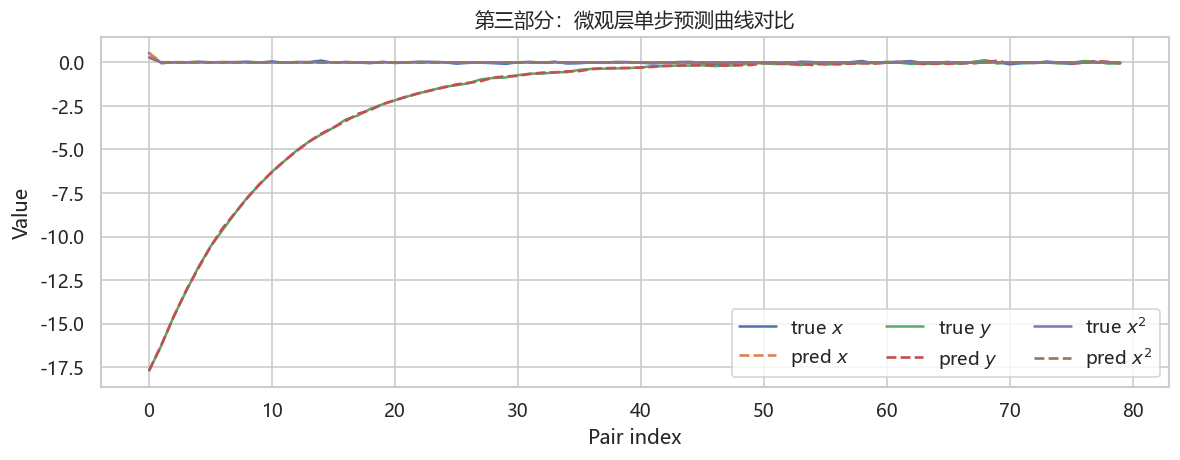

In [15]:
errors3_micro = compute_prediction_errors(A3_micro, obs_part3, tau=analysis_config['tau'], horizons=analysis_config['horizons'])
display(pd.DataFrame({'horizon': list(errors3_micro.keys()), 'mean_error': [errors3_micro[h]['mean_error'] for h in errors3_micro.keys()]}))
pred1_micro, target1_micro = errors3_micro[1]['predictions'], errors3_micro[1]['targets']
plt.figure(figsize=(10,4))
for idx, name in enumerate(feature_names_3):
    plt.plot(np.arange(len(pred1_micro[:80])), target1_micro[:80, idx], label=f'true {name}')
    plt.plot(np.arange(len(pred1_micro[:80])), pred1_micro[:80, idx], '--', linewidth=1.6, label=f'pred {name}')
plt.title('第三部分：微观层单步预测曲线对比')
plt.xlabel('Pair index')
plt.ylabel('Value')
plt.legend(ncol=3)
plt.tight_layout(); plt.show()


### 3.6 微观层 GIS 指标
下面根据 `(A_o, \Sigma_o)` 计算微观层的 `GIS` 指标：近似可逆性、对数近似可逆性、维度平均效率、确定性和非简并性，并画出微观层奇异值谱。这样可以把“预测好不好”和“结构效率高不高”这两类信息分开看。


,metric,value
0,Gamma,1448.228194
1,log_Gamma,7.278096
2,J_alpha,2.426032
3,D,22.820819
4,N,6.291566


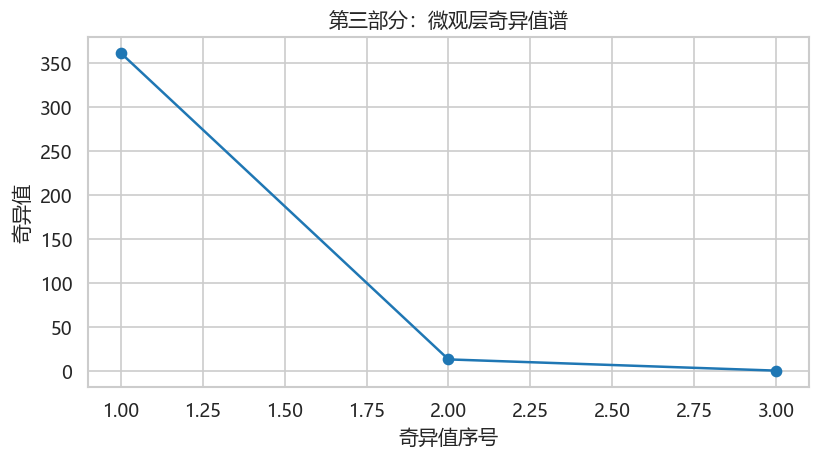

In [16]:
metrics3_micro = compute_gis_metrics(A3_micro, Sigma3_micro, alpha=analysis_config['alpha'], eps=analysis_config['eps'])
display(pd.DataFrame({'metric': ['Gamma','log_Gamma','J_alpha','D','N'], 'value': [metrics3_micro['Gamma'], metrics3_micro['log_Gamma'], metrics3_micro['J_alpha'], metrics3_micro['D'], metrics3_micro['N']]}))
plt.figure(figsize=(7,4))
plt.plot(np.arange(1, len(metrics3_micro['sv_backward'])+1), metrics3_micro['sv_backward'], marker='o', color='tab:blue')
plt.title('第三部分：微观层奇异值谱')
plt.xlabel('奇异值序号')
plt.ylabel('奇异值')
plt.tight_layout(); plt.show()


### 3.7 宏观维度选择与 W 的构造
根据微观层的谱结构选择宏观维度 `r`，再通过 SVD 路线构造粗粒化矩阵 `W`。这一步是从微观层过渡到宏观层的关键，因为后面的宏观变量定义完全由 `W` 决定。


第三部分选定的宏观维度 r = 1


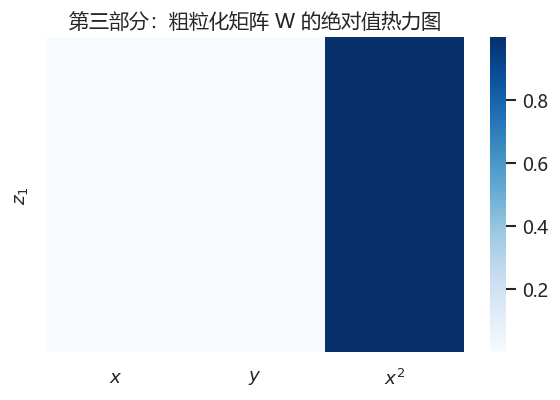

In [17]:
r3, rank_meta3 = select_macro_rank(metrics3_micro['sv_backward'], mode='manual', manual_r=analysis_config['manual_r'], eps=analysis_config['eps'])
W3 = build_w_from_svd(A3_micro, Sigma3_micro, r=r3, alpha=analysis_config['alpha'], eps=analysis_config['eps'], mode='two_stage')['W']
macro_names_3 = [f'$z_{i+1}$' for i in range(r3)]
print('第三部分选定的宏观维度 r =', r3)
plot_matrix_heatmap(np.abs(W3), '第三部分：粗粒化矩阵 W 的绝对值热力图', row_labels=macro_names_3, col_labels=feature_names_3, center=None, figsize=(5, 3.5), cmap='Blues')


### 3.8 宏观数据生成
宏观变量由
\[
\mathbf{z}_t = W \mathbf{o}_t
\]
给出。得到宏观数据后，就可以把同一套配对、拟合和预测过程平移到宏观层。下面先生成宏观时间序列，并构造宏观层的时间配对样本。


In [18]:
z3 = apply_coarse_graining(W3, obs_part3)
Z_now_3, Z_next_3 = prepare_time_pairs(z3, tau=analysis_config['tau'], burn_in=0, stride=1)
print('第三部分宏观数据形状:', z3.shape)
print('第三部分宏观配对样本形状:', Z_now_3.shape, Z_next_3.shape)


第三部分宏观数据形状: (601, 1)
第三部分宏观配对样本形状: (600, 1) (600, 1)


### 3.9 宏观层拟合
在宏观层上重复一次微观层的建模过程：
\[
\mathbf{z}_{t+\tau} \approx A_z \mathbf{z}_t + \varepsilon_t^{(z)},
\qquad
\Sigma_z = \mathrm{Cov}(\mathbf{e}_t^{(z)}).
\]
下面拟合宏观层的 `A_z` 与 `\Sigma_z`，并用热力图展示它们的结构。


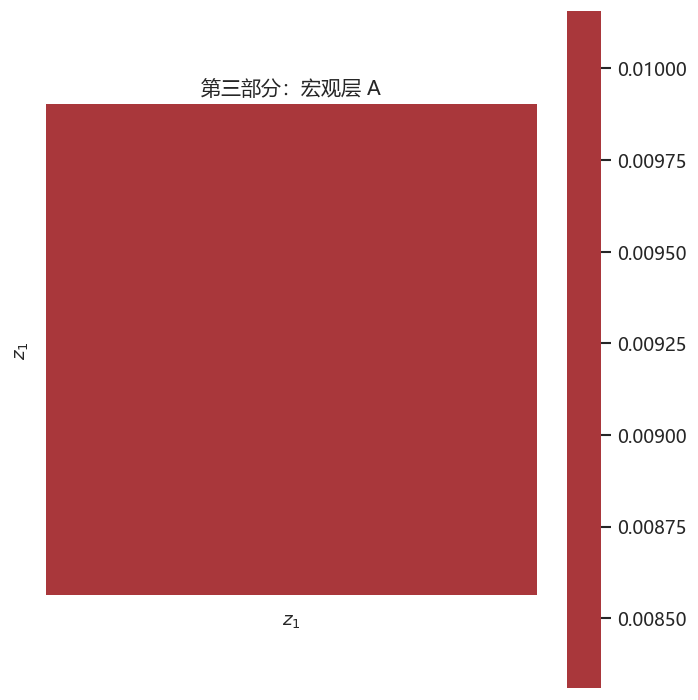

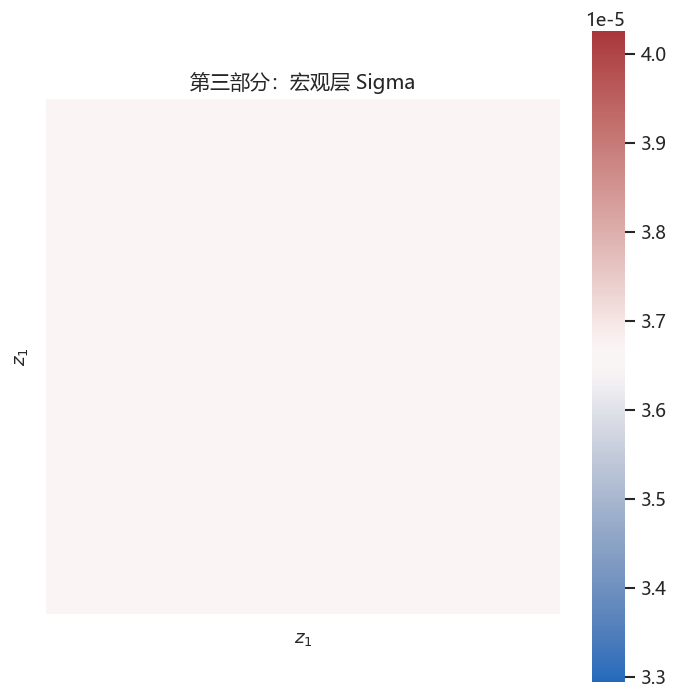

In [19]:
fit3_macro = fit_linear_gis_from_pairs(Z_now_3, Z_next_3, fit_intercept=False, ridge=analysis_config['ridge'], regularization=analysis_config['eps'])
A3_macro, Sigma3_macro = fit3_macro['A'], fit3_macro['Sigma']
plot_matrix_heatmap(A3_macro, '第三部分：宏观层 A', row_labels=macro_names_3, col_labels=macro_names_3, label_step=1)
plot_matrix_heatmap(Sigma3_macro, '第三部分：宏观层 Sigma', row_labels=macro_names_3, col_labels=macro_names_3, center=None, label_step=1)


### 3.10 宏观层预测与误差
宏观层也需要做单步预测和多步滚动预测。这里重点看两件事：第一，宏观模型是否仍然保持良好的闭合性；第二，降维之后误差是否显著恶化。


,horizon,mean_error
0,1,0.000039
1,3,0.000035
2,5,0.000028


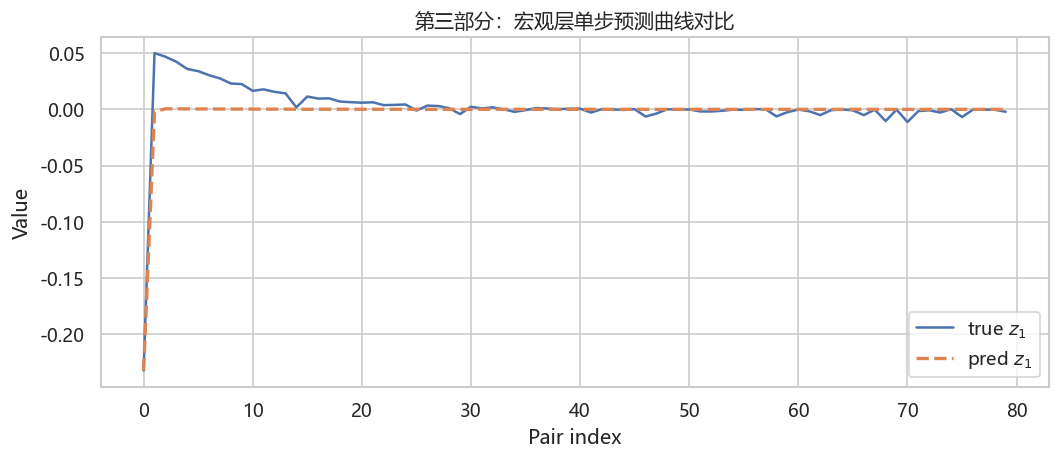

In [20]:
errors3_macro = compute_prediction_errors(A3_macro, z3, tau=analysis_config['tau'], horizons=analysis_config['horizons'])
display(pd.DataFrame({'horizon': list(errors3_macro.keys()), 'mean_error': [errors3_macro[h]['mean_error'] for h in errors3_macro.keys()]}))
pred1_macro, target1_macro = errors3_macro[1]['predictions'], errors3_macro[1]['targets']
plt.figure(figsize=(9,4))
for idx, name in enumerate(macro_names_3):
    plt.plot(np.arange(len(pred1_macro[:80])), target1_macro[:80, idx], label=f'true {name}')
    plt.plot(np.arange(len(pred1_macro[:80])), pred1_macro[:80, idx], '--', linewidth=2.0, label=f'pred {name}')
plt.title('第三部分：宏观层单步预测曲线对比')
plt.xlabel('Pair index')
plt.ylabel('Value')
plt.legend()
plt.tight_layout(); plt.show()


### 3.11 宏观层 GIS 指标
宏观层同样要计算 `Gamma`、`log Gamma`、`J`、`D`、`N`。只有这样，后面得到的 `CE` 才是真正意义上的“宏观效率增益”，而不是只看预测误差后的主观判断。


,metric,value
0,Gamma,15.882853
1,log_Gamma,2.765240
2,J_alpha,2.765240
3,D,10.215449
4,N,0.845511


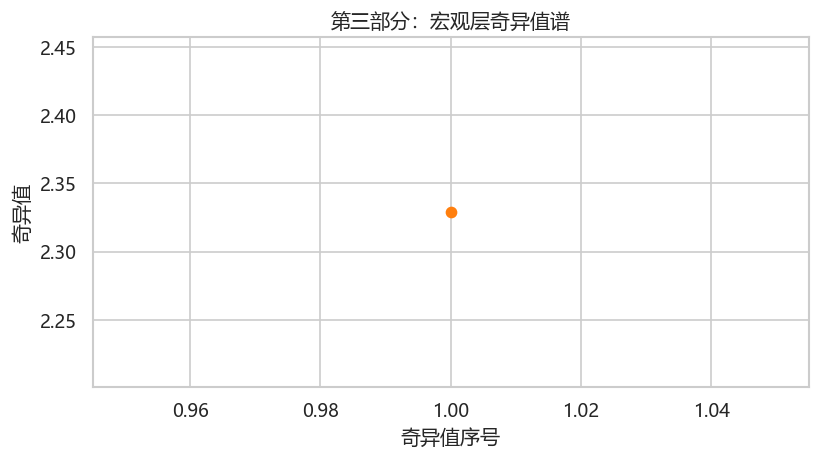

In [21]:
metrics3_macro = compute_gis_metrics(A3_macro, Sigma3_macro, alpha=analysis_config['alpha'], eps=analysis_config['eps'])
display(pd.DataFrame({'metric': ['Gamma','log_Gamma','J_alpha','D','N'], 'value': [metrics3_macro['Gamma'], metrics3_macro['log_Gamma'], metrics3_macro['J_alpha'], metrics3_macro['D'], metrics3_macro['N']]}))
plt.figure(figsize=(7,4))
plt.plot(np.arange(1, len(metrics3_macro['sv_backward'])+1), metrics3_macro['sv_backward'], marker='o', color='tab:orange')
plt.title('第三部分：宏观层奇异值谱')
plt.xlabel('奇异值序号')
plt.ylabel('奇异值')
plt.tight_layout(); plt.show()


### 3.12 CE 值与宏微观曲线对比
下面正式计算
\[
CE = J_{\alpha,z} - J_{\alpha,o}.
\]
与此同时，把代表性的微观变量曲线和宏观变量曲线画在同一张图上。为了避免曲线重合后看不清，这里让微观层使用实线、宏观层使用虚线，并统一做标准化显示。


第三部分 CE = 0.33920807709997414


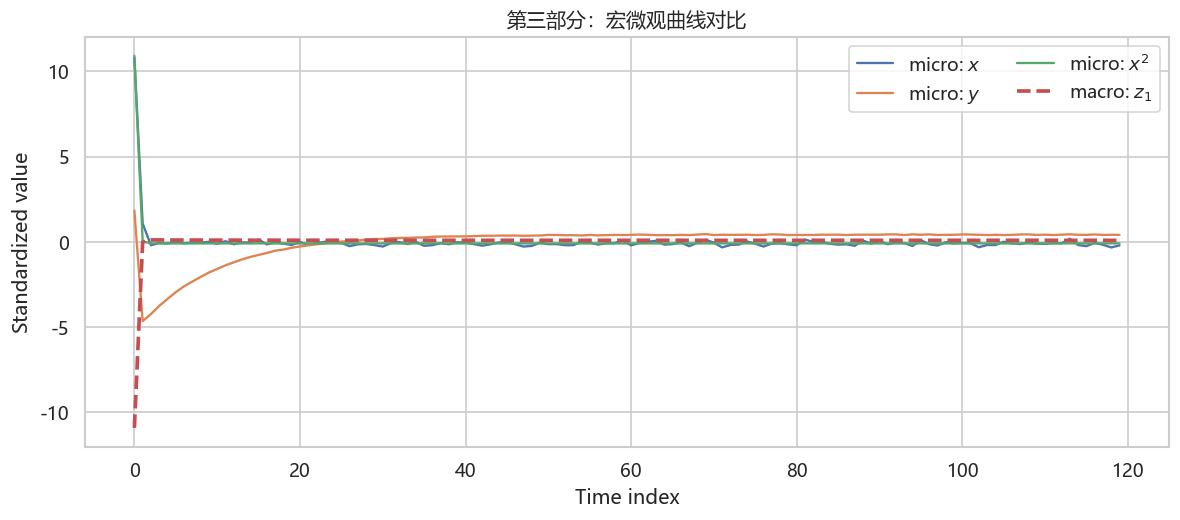

In [22]:
ce3 = compute_ce_from_micro_macro(metrics3_micro, metrics3_macro)
print('第三部分 CE =', ce3['CE'])
plt.figure(figsize=(10,4.5))
for idx, name in enumerate(feature_names_3):
    plt.plot(np.arange(120), standardize_for_plot(obs_part3[:120, idx]), linewidth=1.4, label=f'micro: {name}')
for idx, name in enumerate(macro_names_3):
    plt.plot(np.arange(120), standardize_for_plot(z3[:120, idx]), '--', linewidth=2.2, label=f'macro: {name}')
plt.title('第三部分：宏微观曲线对比')
plt.xlabel('Time index')
plt.ylabel('Standardized value')
plt.legend(ncol=2)
plt.tight_layout(); plt.show()


### 3.13 结果汇总
最后把本次实验的参数、矩阵、误差和指标汇总为一条记录，便于后续做噪声扫描、时间尺度扫描和不同系统之间的横向对比。


In [23]:
summary3_dict, summary3_row = summarize_pipeline_results(
    config={'experiment_name': analysis_config['experiment_name'], 'tau': analysis_config['tau'], 'delta': analysis_config['delta'], 'alpha': analysis_config['alpha'], 'noise_scale': analysis_config['noise_scale']},
    micro_fit=fit3_micro,
    macro_fit=fit3_macro,
    micro_metrics=metrics3_micro,
    macro_metrics=metrics3_macro,
    prediction_results={'micro_errors': errors3_micro, 'macro_errors': errors3_macro},
    ce_result=ce3,
    extra={'W': W3, 'rank_meta': rank_meta3},
)
display(pd.DataFrame([summary3_row]))


,experiment_name,tau,alpha,delta,noise_scale,micro_dim,macro_dim,micro_J_alpha,macro_J_alpha,micro_D,...,micro_N,macro_N,micro_log_Gamma,macro_log_Gamma,CE,delta_D,delta_N,delta_log_Gamma,micro_E1,macro_E1
0,exp_ana_gis_part3,1,1.0,None,0.05,3,1,2.426032,2.76524,22.820819,...,6.291566,0.845511,7.278096,2.76524,0.339208,-12.60537,-5.446054,-4.512856,0.006804,0.000039


## 第四部分：step2 系统下 SVD 与 EVD 的对比

### 4.1 step2 系统与本部分目标
`step2` 系统包含明显的非正交混合作用，因此非常适合比较奇异值分解与特征值分解在宏观方向提取上的差异。这里我们保持同一套数据、同一套 `GIS` 主流程，只改变“构造 `W` 的方法”，从而把两条路线放到同一标准下比较。


In [24]:
def step2_local(x, y, a=0.8, coupling=10.0):
    return a * x + coupling * (y ** 2), a * y

step2_config = {'experiment_name': 'exp_ana_gis_part4_step2', 'initial_state': [0.2, 0.45], 'steps': 220, 'dt': 1.0, 'tau': 1, 'delta': None, 'alpha': 1.0, 'noise_scale': 0.02, 'noise_seed': 7, 'eps': 1e-10, 'ridge': 1e-10, 'manual_r': 1, 'horizons': (1, 3, 5)}
step2_sim = simulate_discrete_system(step2_local, step2_config['initial_state'], steps=step2_config['steps'], system_kwargs={'a': 0.8, 'coupling': 10.0}, dt=step2_config['dt'])
step2_clean, step2_time = step2_sim['trajectories'][0], step2_sim['time_grid']
step2_noisy = add_gaussian_noise(step2_clean, noise_scale=step2_config['noise_scale'], cov=None, random_state=step2_config['noise_seed'])['noisy_data']


### 4.2 step2 系统数据轨迹与相图
这里先画出 `step2` 系统的相图。这个图的意义在于：后面的 SVD / EVD 差异不只是一组数值差异，还能和轨迹在几何上的主伸缩方向联系起来。


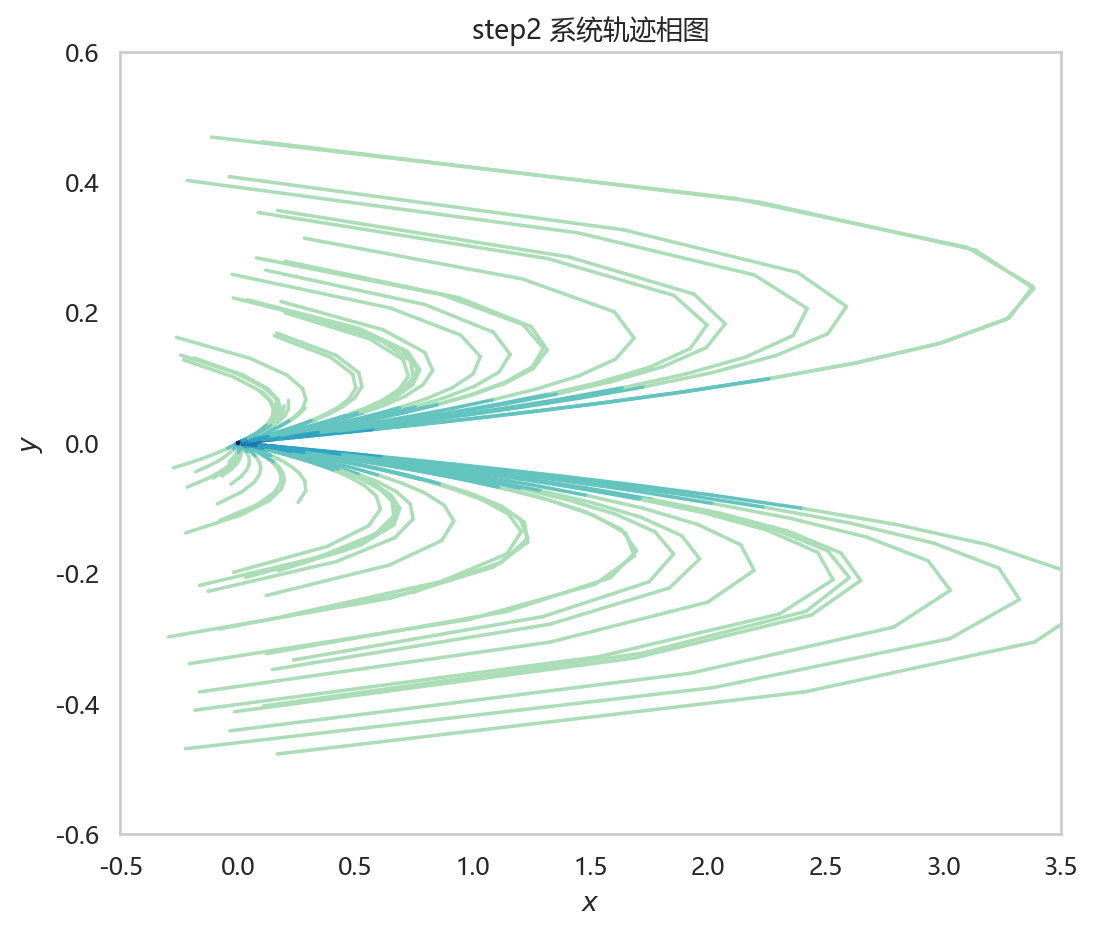

In [25]:
fig, ax = plt.subplots(figsize=(7, 6), dpi=160)
rng = np.random.default_rng(42)
initial_points = np.vstack([rng.uniform(-0.3, 0.3, 60), rng.uniform(-0.5, 0.5, 60)]).T
custom_cmap = ListedColormap(plt.cm.YlGnBu(np.linspace(0.3, 0.95, 6)))
for x0, y0 in initial_points:
    traj = simulate_discrete_system(step2_local, [x0, y0], steps=120, system_kwargs={'a': 0.8, 'coupling': 10.0}, dt=1.0)['trajectories'][0]
    points = traj.reshape(-1, 1, 2); segments = np.concatenate([points[:-1], points[1:]], axis=1); color_idx = np.arange(len(segments)); color_idx[np.where(color_idx > 40)] = 40
    lc = LineCollection(segments, cmap=custom_cmap); lc.set_array(color_idx); lc.set_linewidth(1.6); lc.set_capstyle('round'); ax.add_collection(lc)
ax.set_xlabel('$x$'); ax.set_ylabel('$y$'); ax.set_title('step2 系统轨迹相图'); ax.set_xlim([-0.5, 3.5]); ax.set_ylim([-0.6, 0.6]); ax.grid(False); plt.tight_layout(); plt.show()


### 4.3 标准 SVD 路线的完整流程
下面在 `step2` 数据上走标准 SVD 版本的附录 D 主流程。也就是说，宏观维度与粗粒化矩阵 `W` 都由 SVD 路线给出，其余建模、指标和预测步骤完全不变。


In [26]:
obs_step2 = observable_step2(step2_noisy, mode='default')
res_step2_svd = run_gis_pipeline_from_observations(obs_step2, tau=step2_config['tau'], alpha=step2_config['alpha'], delta=step2_config['delta'], eps=step2_config['eps'], ridge=step2_config['ridge'], manual_r=step2_config['manual_r'], horizons=step2_config['horizons'], w_method='svd')
print('step2 - SVD 路线 CE =', res_step2_svd['ce_result']['CE'])


step2 - SVD 路线 CE = 0.9896504840427189


### 4.4 EVD 路线的完整流程
这里保持同样的数据、观测函数和时间尺度，只把宏观方向提取方法从 SVD 换成 EVD。对于复特征值，谱比较时统一取模长；若特征值为负，也统一按绝对值排序比较，以便和奇异值谱放在同一尺度上解释。


In [27]:
res_step2_evd = run_gis_pipeline_from_observations(obs_step2, tau=step2_config['tau'], alpha=step2_config['alpha'], delta=step2_config['delta'], eps=step2_config['eps'], ridge=step2_config['ridge'], manual_r=step2_config['manual_r'], horizons=step2_config['horizons'], w_method='evd', evd_mode='eig_abs')
print('step2 - EVD 路线 CE =', res_step2_evd['ce_result']['CE'])


step2 - EVD 路线 CE = -2.2375990853312064


### 4.5 奇异值谱与特征值谱的对比
下面把 `step2` 系统微观层矩阵的奇异值谱与特征值谱放在同一张图中比较。这个图主要回答的问题是：两种分解强调的主方向是否一致，还是它们实际上在看动力学矩阵的不同侧面。


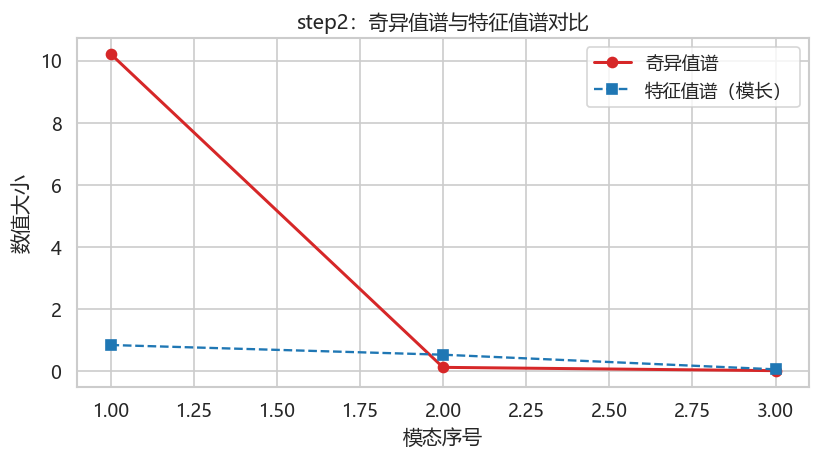

In [28]:
A_step2_micro = res_step2_svd['micro_fit']['A']
sv_step2 = np.linalg.svd(A_step2_micro, compute_uv=False)
eig_abs_step2 = np.sort(np.abs(np.linalg.eigvals(A_step2_micro)))[::-1]
plt.figure(figsize=(7,4))
plt.plot(np.arange(1, len(sv_step2)+1), sv_step2, marker='o', linewidth=1.8, label='奇异值谱', color='tab:red')
plt.plot(np.arange(1, len(eig_abs_step2)+1), eig_abs_step2, marker='s', linewidth=1.4, linestyle='--', label='特征值谱（模长）', color='tab:blue')
plt.title('step2：奇异值谱与特征值谱对比')
plt.xlabel('模态序号')
plt.ylabel('数值大小')
plt.legend(); plt.tight_layout(); plt.show()


### 4.6 两种情况下的粗粒化矩阵对比
粗粒化矩阵反映了宏观变量到底是由哪些观测变量组合而成。下面分别画出 SVD 与 EVD 路线得到的 `W`，用热力图观察两种方法提取出的宏观方向是否一致。


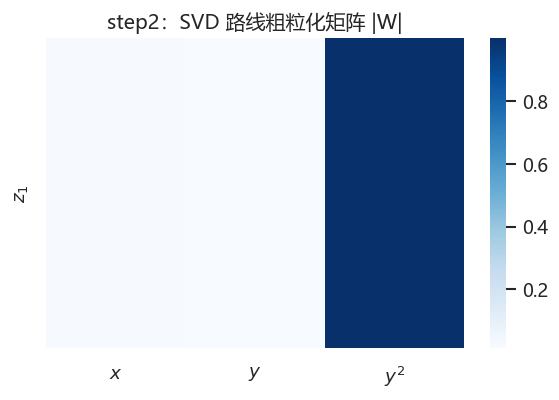

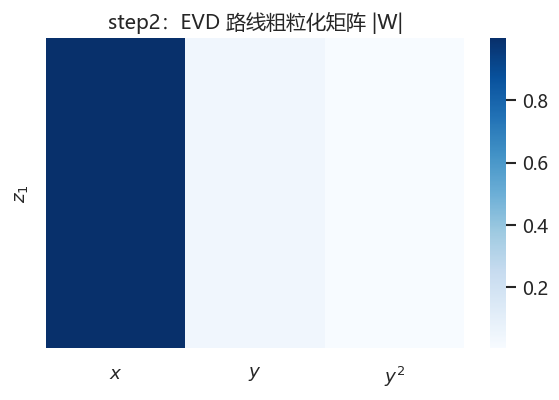

In [29]:
step2_feature_names = ['$x$', '$y$', '$y^2$']
step2_macro_names = [f'$z_{i+1}$' for i in range(res_step2_svd['W'].shape[0])]
plot_matrix_heatmap(np.abs(res_step2_svd['W']), 'step2：SVD 路线粗粒化矩阵 |W|', row_labels=step2_macro_names, col_labels=step2_feature_names, center=None, figsize=(5, 3.5), cmap='Blues')
plot_matrix_heatmap(np.abs(res_step2_evd['W']), 'step2：EVD 路线粗粒化矩阵 |W|', row_labels=step2_macro_names, col_labels=step2_feature_names, center=None, figsize=(5, 3.5), cmap='Blues')


### 4.7 两种方法下的宏微观曲线对比
这里把微观曲线、SVD 宏观曲线和 EVD 宏观曲线放在同一张图上。为避免曲线重合后看不清，微观层使用实线，SVD 宏观使用虚线，EVD 宏观使用点划线，并对每条曲线做标准化处理。


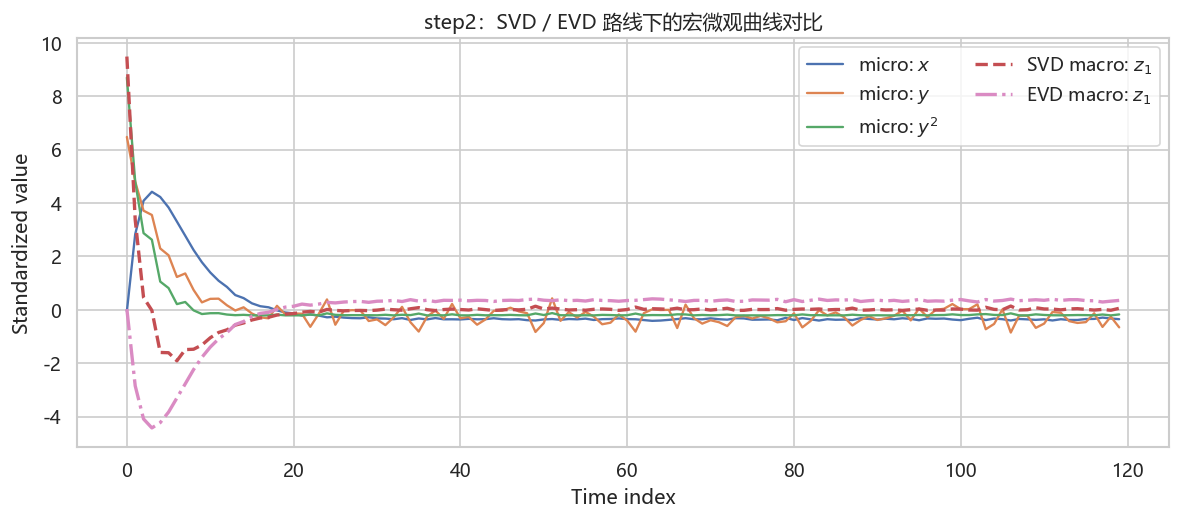

In [30]:
plt.figure(figsize=(10,4.5))
for idx, name in enumerate(step2_feature_names):
    plt.plot(np.arange(120), standardize_for_plot(obs_step2[:120, idx]), linewidth=1.4, label=f'micro: {name}')
for idx in range(res_step2_svd['macro_observations'].shape[1]):
    plt.plot(np.arange(120), standardize_for_plot(res_step2_svd['macro_observations'][:120, idx]), '--', linewidth=2.0, color=f'C{idx+3}', label=f'SVD macro: $z_{idx+1}$')
for idx in range(res_step2_evd['macro_observations'].shape[1]):
    plt.plot(np.arange(120), standardize_for_plot(res_step2_evd['macro_observations'][:120, idx]), '-.', linewidth=2.0, color=f'C{idx+6}', label=f'EVD macro: $z_{idx+1}$')
plt.title('step2：SVD / EVD 路线下的宏微观曲线对比')
plt.xlabel('Time index')
plt.ylabel('Standardized value')
plt.legend(ncol=2)
plt.tight_layout(); plt.show()


### 4.8 核心数值比较与结论
最后汇总 `step2` 系统下 SVD 与 EVD 两条路线的核心数值，包括 `CE`、宏微观维度平均效率和对数近似可逆性。这样可以把“图像上的差异”和“指标上的差异”放在一起读。


In [31]:
display(pd.DataFrame([
    {'method': 'SVD', 'micro_J_alpha': res_step2_svd['micro_metrics']['J_alpha'], 'macro_J_alpha': res_step2_svd['macro_metrics']['J_alpha'], 'micro_log_Gamma': res_step2_svd['micro_metrics']['log_Gamma'], 'macro_log_Gamma': res_step2_svd['macro_metrics']['log_Gamma'], 'CE': res_step2_svd['ce_result']['CE']},
    {'method': 'EVD', 'micro_J_alpha': res_step2_evd['micro_metrics']['J_alpha'], 'macro_J_alpha': res_step2_evd['macro_metrics']['J_alpha'], 'micro_log_Gamma': res_step2_evd['micro_metrics']['log_Gamma'], 'macro_log_Gamma': res_step2_evd['macro_metrics']['log_Gamma'], 'CE': res_step2_evd['ce_result']['CE']}
]))


,method,micro_J_alpha,macro_J_alpha,micro_log_Gamma,macro_log_Gamma,CE
0,SVD,4.05825,5.047901,12.174751,5.047901,0.989650
1,EVD,4.05825,1.820651,12.174751,1.820651,-2.237599


## 第五部分：结尾统一摘要

### 5.1 统一结论
最后用少量核心数值把四个部分串起来：第一部分提供参数与谱的直观背景，第二部分验证矩阵层面的宏微比较逻辑，第三部分给出含噪数据下的完整 `GIS` 主流程，第四部分则展示在 `step2` 系统上 SVD 与 EVD 会如何导出不同的宏观方向与 `CE` 结果。


In [32]:
final_summary = {
    'part2_direct_matrix_ce': direct_ce['CE'],
    'part3_noisy_pipeline_ce': ce3['CE'],
    'part4_step2_svd_ce': res_step2_svd['ce_result']['CE'],
    'part4_step2_evd_ce': res_step2_evd['ce_result']['CE'],
}
print('统一摘要：')
for key, value in final_summary.items():
    print(f'{key}: {value:.6f}')
display(pd.DataFrame([
    {'part': '解析矩阵 A', 'CE': direct_ce['CE']},
    {'part': '含噪数据完整流程', 'CE': ce3['CE']},
    {'part': 'step2 - SVD', 'CE': res_step2_svd['ce_result']['CE']},
    {'part': 'step2 - EVD', 'CE': res_step2_evd['ce_result']['CE']},
]))


统一摘要：
part2_direct_matrix_ce: 1.118896
part3_noisy_pipeline_ce: 0.339208
part4_step2_svd_ce: 0.989650
part4_step2_evd_ce: -2.237599


,part,CE
0,解析矩阵 A,1.118896
1,含噪数据完整流程,0.339208
2,step2 - SVD,0.989650
3,step2 - EVD,-2.237599
